# Solving the Inverse Problem

This notebook shows the code of solving the inverse problem and estimating the PDE parameters. 

In [1]:
import os
import sys
import glob
import h5py
import torch as t
import numpy as np
from torch import nn
import multiprocessing
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from timm.models.layers import trunc_normal_

/tmp/chenxingzhuo/StaDiff/lib/python3.12/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


# Parameters 

We will use the pre-trained PICON network stored in "modelSaveDir" for the inverse problem, and pick a numerical simulation instance in the testing data set for example.  
This prediction uses 32 pairs of plasma snapshots as defined in "predSize", please double check the GPU memory space when you are running the code.  
The solution will be stored in "invSaveDir/".  

In [3]:
modelSaveDir='OperatorSaverPIC3XFL/lr0.0003/'
sfNameOne='FiveHWRunner/storeField_3_12.h5'
predSize=32
invSaveDir='InverseSaver/32Point/'

## Load the Neural Network

In [4]:
timeGrid=0.005
gridNum=128
muVal=5e-10

uD2k=t.meshgrid(*[t.fft.fftfreq(int(n)) for n in (gridNum,gridNum)],indexing="ij")
uD2k=t.stack(uD2k,-1)
uD2k=t.sum(uD2k**2,axis=-1).cuda()
fft_laplace=-((2*np.pi)**2)*uD2k
fft_laplace[0,0]=np.inf

def unwrapDelta2(tensor,dx):
    frequencies=t.fft.fft2(tensor)
    result=frequencies/(fft_laplace)
    result=t.where(fft_laplace==0,0,result)
    result=t.real(t.fft.ifft2(result))
    return result*dx**2
def periodicLaplace(fieldIn,dx):
    fieldPad=nn.functional.pad(fieldIn,(1,1,1,1),'circular')
    fieldOut=fieldPad[:,0:-2,1:-1]+fieldPad[:,1:-1,0:-2]-4*fieldPad[:,1:-1,1:-1]+fieldPad[:,1:-1,2:]+fieldPad[:,2:,1:-1]
    return fieldOut/dx**2
def arakawaVec(zeta,psi,dx):
    return (zeta[:,1:-1,2:  ]*(psi[:,2:  ,1:-1]-psi[:,0:-2,1:-1]+psi[:,2:  ,2:  ]-psi[:,0:-2,2:  ])
           -zeta[:,1:-1,0:-2]*(psi[:,2:  ,1:-1]-psi[:,0:-2,1:-1]+psi[:,2:  ,0:-2]-psi[:,0:-2,0:-2])
           -zeta[:,2:  ,1:-1]*(psi[:,1:-1,2:  ]-psi[:,1:-1,0:-2]+psi[:,2:  ,2:  ]-psi[:,2:  ,0:-2])
           +zeta[:,0:-2,1:-1]*(psi[:,1:-1,2:  ]-psi[:,1:-1,0:-2]+psi[:,0:-2,2:  ]-psi[:,0:-2,0:-2])
           +zeta[:,0:-2,2:  ]*(psi[:,1:-1,2:  ]-psi[:,0:-2,1:-1])
           +zeta[:,2:  ,2:  ]*(psi[:,2:  ,1:-1]-psi[:,1:-1,2:  ])
           -zeta[:,2:  ,0:-2]*(psi[:,2:  ,1:-1]-psi[:,1:-1,0:-2])
           -zeta[:,0:-2,0:-2]*(psi[:,1:-1,0:-2]-psi[:,0:-2,1:-1]))/(12*dx**2)
def hwCalTD(omegaDenIn,c1,kappa,pbc,spaGrid):
    phi1=unwrapDelta2(omegaDenIn[:,0],spaGrid)

    phiPad=nn.functional.pad(phi1,(1,1,1,1),'circular')
    denPad=nn.functional.pad(omegaDenIn[:,1],(1,1,1,1),'circular')
    phi1X=(phiPad[:,2:,1:-1]-phiPad[:,0:-2,1:-1])/(2*spaGrid)
    phi1Y=(phiPad[:,1:-1,2:]-phiPad[:,1:-1,0:-2])/(2*spaGrid)
    den1X=(denPad[:,2:,1:-1]-denPad[:,0:-2,1:-1])/(2*spaGrid)
    den1Y=(denPad[:,1:-1,2:]-denPad[:,1:-1,0:-2])/(2*spaGrid)
    omegaPad=nn.functional.pad(omegaDenIn[:,0],(1,1,1,1),'circular')
    omega1X=(omegaPad[:,2:,1:-1]-omegaPad[:,0:-2,1:-1])/(2*spaGrid)
    omega1Y=(omegaPad[:,1:-1,2:]-omegaPad[:,1:-1,0:-2])/(2*spaGrid)
    diffuTermDen=periodicLaplace(periodicLaplace(periodicLaplace(omegaDenIn[:,1],spaGrid),spaGrid),spaGrid)
    diffuTermOmg=periodicLaplace(periodicLaplace(periodicLaplace(omegaDenIn[:,0],spaGrid),spaGrid),spaGrid)
    denT1=c1.view([-1,1,1])*(phi1-omegaDenIn[:,1])-pbc.view([-1,1,1])*arakawaVec(phiPad,denPad,spaGrid)-kappa.view([-1,1,1])*phi1X+muVal*diffuTermDen
    omegaT1=c1.view([-1,1,1])*(phi1-omegaDenIn[:,1])-pbc.view([-1,1,1])*arakawaVec(phiPad,omegaPad,spaGrid)+muVal*diffuTermOmg
    
    omegaDenT=t.stack([omegaT1,denT1],axis=1)
    return omegaDenT

def rk4DiffCal(omegaDenIn,c1,kappa,pbc,spaGrid,tGrid):
    omegaDenT1=hwCalTD(omegaDenIn,c1,kappa,pbc,spaGrid)
    omegaDenIn2=omegaDenIn+omegaDenT1*tGrid.view([-1,1,1,1])/2
    omegaDenT2=hwCalTD(omegaDenIn2,c1,kappa,pbc,spaGrid)
    omegaDenIn3=omegaDenIn+omegaDenT2*tGrid.view([-1,1,1,1])/2
    omegaDenT3=hwCalTD(omegaDenIn3,c1,kappa,pbc,spaGrid)
    omegaDenIn4=omegaDenIn+omegaDenT3*tGrid.view([-1,1,1,1])
    omegaDenT4=hwCalTD(omegaDenIn4,c1,kappa,pbc,spaGrid)
    omegaDenDiff=(omegaDenT1+2*omegaDenT2+2*omegaDenT3+omegaDenT4)*tGrid.view([-1,1,1,1])/6
    return omegaDenDiff

class LayerNorm(nn.Module):
    """ LayerNorm that supports two data formats: channels_last (default) or channels_first. 
    The ordering of the dimensions in the inputs. channels_last corresponds to inputs with 
    shape (batch_size, height, width, channels) while channels_first corresponds to inputs 
    with shape (batch_size, channels, height, width).
    """
    def __init__(self,normalized_shape,eps=1e-6,data_format="channels_last"):
        super().__init__()
        self.weight=nn.Parameter(t.ones(normalized_shape))
        self.bias=nn.Parameter(t.zeros(normalized_shape))
        self.eps=eps
        self.data_format=data_format
        if self.data_format not in ["channels_last","channels_first"]:
            raise NotImplementedError 
        self.normalized_shape=(normalized_shape,)
    def forward(self,x):
        if self.data_format=="channels_last":
            return t.nn.functional.layer_norm(x,self.normalized_shape,self.weight,self.bias,self.eps)
        elif self.data_format == "channels_first":
            u=x.mean(1,keepdim=True)
            s=(x-u).pow(2).mean(1,keepdim=True)
            x=(x-u)/t.sqrt(s+self.eps)
            x=self.weight[:,None,None]*x+self.bias[:,None,None]
            return x

class GRN(nn.Module): #GRN (Global Response Normalization) layer
    def __init__(self,dim):
        super().__init__()
        self.gamma=nn.Parameter(t.zeros(1,1,1,dim))
        self.beta=nn.Parameter(t.zeros(1,1,1,dim))
    def forward(self,x):
        Gx=t.norm(x,p=2,dim=(1,2),keepdim=True)
        Nx=Gx/(Gx.mean(dim=-1,keepdim=True)+1e-6)
        return self.gamma*(x*Nx)+self.beta+x

class Block(nn.Module):
    """ ConvNeXtV2 Block.
    Args:
        dim (int): Number of input channels.
        drop_path (float): Stochastic depth rate. Default: 0.0
    """
    def __init__(self,dim,drop_path=0.0):
        super().__init__()
        self.dwconv=nn.Conv2d(dim,dim,kernel_size=7,padding=3,groups=dim,padding_mode='circular') # depthwise conv
        self.norm=LayerNorm(dim, eps=1e-6)
        self.pwconv1=nn.Linear(dim,4*dim) # pointwise/1x1 convs, implemented with linear layers
        self.act=nn.GELU()
        self.grn=GRN(4*dim)
        self.pwconv2=nn.Linear(4*dim,dim)
        self.drop_path=DropPath(drop_path) if drop_path>0.0 else nn.Identity()
    def forward(self,x):
        input=x
        x=self.dwconv(x)
        x=x.permute(0,2,3,1)# (N, C, H, W) -> (N, H, W, C)
        x=self.norm(x)
        x=self.pwconv1(x)
        x=self.act(x)
        x=self.grn(x)
        x=self.pwconv2(x)
        x=x.permute(0,3,1,2)# (N, H, W, C) -> (N, C, H, W)
        x=input+self.drop_path(x)
        return x

class ConvNeXtV2(nn.Module):
    """ ConvNeXt V2
    Args:
        in_chans (int): Number of input image channels. Default: 3
        num_classes (int): Number of classes for classification head. Default: 1000
        depths (tuple(int)): Number of blocks at each stage. Default: [3, 3, 9, 3]
        dims (int): Feature dimension at each stage. Default: [96, 192, 384, 768]
        drop_path_rate (float): Stochastic depth rate. Default: 0.
        head_init_scale (float): Init scaling value for classifier weights and biases. Default: 1.
    """
    def __init__(self,in_chans=8,out_channel=2,depths=[3,3,9,3],dims=[96,192,384,768],drop_path_rate=0.0,head_init_scale=1.0):
        super().__init__()
        self.depths=depths
        self.num_stage=len(depths)
        self.downsample_layers=nn.ModuleList() # stem and 3 intermediate downsampling conv layers
        stem = nn.Sequential(nn.Conv2d(in_chans,dims[0],kernel_size=2,stride=2),
                             LayerNorm(dims[0],eps=1e-6,data_format="channels_first"))
        self.downsample_layers.append(stem)
        for i in range(self.num_stage-1):
            downsample_layer=nn.Sequential(LayerNorm(dims[i],eps=1e-6,data_format="channels_first"),
                                           nn.Conv2d(dims[i],dims[i+1],kernel_size=2,stride=2))
            self.downsample_layers.append(downsample_layer)
        self.stages=nn.ModuleList() # 4 feature resolution stages, each consisting of multiple residual blocks
        dp_rates=[x.item() for x in t.linspace(0,drop_path_rate,sum(depths))] 
        cur=0
        for i in range(self.num_stage):
            stage=nn.Sequential(*[Block(dim=dims[i],drop_path=dp_rates[cur+j]) for j in range(depths[i])])
            self.stages.append(stage)
            cur+=depths[i]
        self.norm=nn.LayerNorm(dims[-1],eps=1e-6)# final norm layer
        self.out_conv=nn.Conv2d(int(dims[0]/2),out_channel,kernel_size=1) # final classifier conv
        self.upsample_layers=nn.ModuleList() # stem and 3 intermediate downsampling conv layers
        for i in reversed(range(self.num_stage)):
            upsample_layer = nn.Sequential(LayerNorm(dims[i]*2,eps=1e-6,data_format="channels_first"),
                                           nn.ConvTranspose2d(dims[i]*2,int(dims[i]/2),kernel_size=2,stride=2))
            self.upsample_layers.append(upsample_layer)
        self.apply(self._init_weights)
    def _init_weights(self,m):
        if isinstance(m,(nn.Conv2d,nn.Linear)):
            trunc_normal_(m.weight,std=0.02)
            nn.init.constant_(m.bias,0)
    def Encoder(self,x):
        down_features=[]
        for i in range(self.num_stage):
            x=self.downsample_layers[i](x)
            x=self.stages[i](x)
            down_features.append(x)
        return x,down_features
    def Decoder(self,x,down_features):
        for i in range(self.num_stage):
            x=t.cat([x,down_features.pop()],dim=1)
            x=self.upsample_layers[i](x)
        return x
    def forward(self,x):
        x,down_features=self.Encoder(x)
        x=self.Decoder(x, down_features)
        #x=self.norm(x)#Gesa: The copy code forgot to use this norm layer, and the norm layer seems in wrong shape
        x=self.out_conv(x)
        return x
PICNXnet=ConvNeXtV2().float().cuda()
PICNXnet=t.load(modelSaveDir+'PICNX.pt',weights_only=False).double().eval()
chanRescale=t.tensor([100,20]).reshape([1,2,1,1]).double().cuda()

## Load the Data

We will randomly select 32 pairs of the input/output plasma state pairs to estimate the PDE parameters. 

In [ ]:
with h5py.File(sfNameOne) as h5File:
    dens=np.array(h5File['density'])
    omega=np.array(h5File['omega'])
    phi=np.array(h5File['phi'])

ind1=int(sfNameOne.split('/')[-1].split('.h5')[0].split('_')[1])
ind2=int(sfNameOne.split('/')[-1].split('.h5')[0].split('_')[2])

timeList=np.arange(len(dens))*timeGrid
mask=(dens.max(axis=(1,2))>2)&(dens.max(axis=(1,2))<20)
dens=dens[mask]
phi=phi[mask]
omega=omega[mask]
timeList=timeList[mask]

LBox=2*np.pi/k0
spaGrid=(LBox/gridNum).reshape([-1,1,1])

tStartIndex=np.random.choice(range(len(timeList)-2000),size=predSize,replace=False)+1000
tEndIndex=tStartIndex+np.random.choice(range(1,199),size=predSize,replace=True)
timeOne=(tEndIndex-tStartIndex)*timeGrid

omegaPhiDenInSeq=t.hstack([t.tensor(omega[tStartIndex.reshape(-1,1)]),
                           t.tensor(phi[tStartIndex.reshape(-1,1)]),
                           t.tensor(dens[tStartIndex.reshape(-1,1)])]).double().cuda()
omegaPhiDenTrue=t.hstack([t.tensor(omega[tEndIndex.reshape(-1,1)]),
                          t.tensor(phi[tEndIndex.reshape(-1,1)]),
                          t.tensor(dens[tEndIndex.reshape(-1,1)])]).double().cuda()

## Inverse Solution

The solution during the iteration is stored in a list. It usually takes 15 minutes to finish 400 iterations of inference, but the result should be accurate enough at around ~100 steps.  

In [ ]:
Gvals=nn.Parameter(t.tensor([[[1,0.6,1,1]]],requires_grad=True,device='cuda').double())
optimHWE=t.optim.AdamW([Gvals],0.01)

lossList=[]
c1Hist=[]
k0Hist=[]
kappaHist=[]
pbcHist=[]

for k in range(400):
    optimHWE.zero_grad()
    PICNXnet.zero_grad()
    tDiffSeq=t.tensor(timeOne).reshape([-1,1]).double().cuda()
    omegaPhiDenPred=omegaPhiDenInSeq.clone().detach()
    
    OPDTCKKP=t.cat([omegaPhiDenInSeq,
                    tDiffSeq.reshape([-1,1,1,1])*t.ones([1,1,gridNum,gridNum]).cuda(),
                    Gvals[:,:,0]*t.ones([predSize,1,gridNum,gridNum]).cuda(),
                    Gvals[:,:,1]*t.ones([predSize,1,gridNum,gridNum]).cuda(),
                    Gvals[:,:,2]*t.ones([predSize,1,gridNum,gridNum]).cuda(),
                    Gvals[:,:,3]*t.ones([predSize,1,gridNum,gridNum]).cuda()
                   ],axis=1)
    Encoded,midStage=PICNXnet.Encoder(OPDTCKKP)
    omegaDenPred=PICNXnet.out_conv(PICNXnet.Decoder(Encoded,midStage))*tDiffSeq.reshape([-1,1,1,1])*chanRescale+omegaPhiDenInSeq[:,[0,2]]
    omegaPhiDenPred=t.cat([omegaDenPred[:,[0]],unwrapDelta2(omegaDenPred[:,0],spaGrid)[:,None],omegaDenPred[:,[1]]],axis=1)
    omegaPhiDenPred=omegaPhiDenPred-t.mean(omegaPhiDenPred,axis=(2,3),keepdims=True)
    
    diffMse=t.mean((omegaPhiDenPred[:,0]-omegaPhiDenTrue[:,0])**2)
    print(diffMse.item(),Gvals,k)
    lossList.append(diffMse.item())
    c1Hist.append(Gvals[:,:,0].item())
    k0Hist.append(Gvals[:,:,1].item())
    kappaHist.append(Gvals[:,:,2].item())
    pbcHist.append(Gvals[:,:,3].item())
    
    diffMse.backward()
    optimHWE.step()
c1Hist=np.array(c1Hist)
k0Hist=np.array(k0Hist)
kappaHist=np.array(kappaHist)
pbcHist=np.array(pbcHist)
lossList=np.array(lossList)

np.save(invSaveDir+'inverSeq_'+str(ind1)+'_'+str(ind2)+'.npy',np.stack([c1Hist,k0Hist,kappaHist,pbcHist,lossList]))

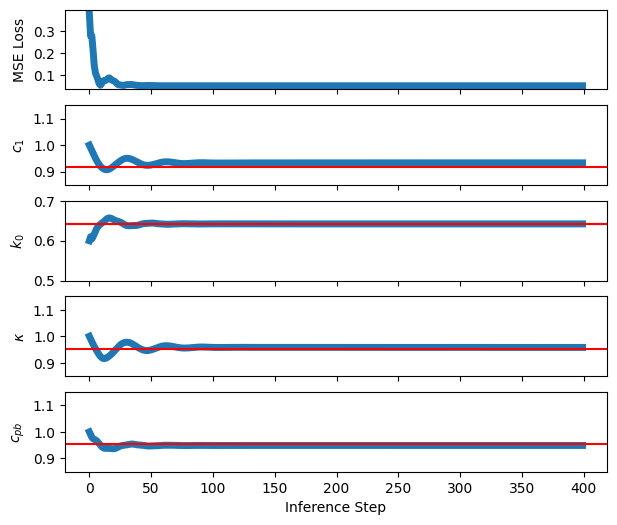

In [8]:
sfNameOne='FiveHWRunner/storeField_3_12.h5'

ind1=int(sfNameOne.split('/')[-1].split('.h5')[0].split('_')[1])
ind2=int(sfNameOne.split('/')[-1].split('.h5')[0].split('_')[2])
c1=np.load('FiveHWRunner/c1List_'+str(ind1)+'.npy')[ind2]
k0=np.load('FiveHWRunner/k0List_'+str(ind1)+'.npy')[ind2]
kappa=np.load('FiveHWRunner/kappaList_'+str(ind1)+'.npy')[ind2]
pbc=np.load('FiveHWRunner/pbcList_'+str(ind1)+'.npy')[ind2]

c1=t.tensor([[c1]]).double().cuda()
k0=t.tensor([[k0]]).double().cuda()

kappa=t.tensor([[kappa]]).double().cuda()
pbc=t.tensor([[pbc]]).double().cuda()

LBox=2*np.pi/k0
spaGrid=(LBox/gridNum).reshape([-1,1,1])

c1Hist,k0Hist,kappaHist,pbcHist,lossList=np.load('InverseSaver/32Point/inverSeq_3_12.npy')

plt.subplot(5,1,1)
plt.plot(lossList,linewidth=5)
plt.ylabel('MSE Loss')
plt.xticks(visible=False)

plt.subplot(5,1,2)
plt.plot(c1Hist,linewidth=5)
plt.axhline(c1.item(),c='r')
plt.ylim(0.85,1.15)
plt.ylabel(r'$c_{1}$')
plt.xticks(visible=False)

plt.subplot(5,1,3)
plt.plot(k0Hist,linewidth=5)
plt.axhline(k0.item(),c='r')
plt.axhline(k0.item(),c='r')
plt.ylim(0.5,0.7)
plt.ylabel(r'$k_{0}$')
plt.xticks(visible=False)

plt.subplot(5,1,4)
plt.plot(kappaHist,linewidth=5)
plt.axhline(kappa.item(),c='r')
plt.ylim(0.85,1.15)
plt.ylabel(r'$\kappa$')
plt.xticks(visible=False)

plt.subplot(5,1,5)
plt.plot(pbcHist,linewidth=5)
plt.axhline(pbc.item(),c='r')
plt.ylim(0.85,1.15)
plt.ylabel(r'$c_{pb}$')
plt.xlabel('Inference Step')
plt.gcf().set_size_inches(7,6)